## Decision Tree
---

In [228]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [229]:
data = pd.read_csv(r"D:\Courses\DEPI R4 - Microsoft ML\Technical\Datasets\Machine Learning\PlayTennis.csv")
data.head()

,Outlook,Temperature,Humidity,Wind,Play Tennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes


In [230]:
outlook_encoder = OrdinalEncoder()
data["Outlook"] = outlook_encoder.fit_transform(data[["Outlook"]])
data.head()

,Outlook,Temperature,Humidity,Wind,Play Tennis
0,2.0,Hot,High,Weak,No
1,2.0,Hot,High,Strong,No
2,0.0,Hot,High,Weak,Yes
3,1.0,Mild,High,Weak,Yes
4,1.0,Cool,Normal,Weak,Yes


In [231]:
tempreature_encoder = OrdinalEncoder()
data["Temperature"] = tempreature_encoder.fit_transform(data[["Temperature"]])
data.head()

,Outlook,Temperature,Humidity,Wind,Play Tennis
0,2.0,1.0,High,Weak,No
1,2.0,1.0,High,Strong,No
2,0.0,1.0,High,Weak,Yes
3,1.0,2.0,High,Weak,Yes
4,1.0,0.0,Normal,Weak,Yes


In [232]:
humudity_encoder = OrdinalEncoder()
data["Humidity"] = humudity_encoder.fit_transform(data[["Humidity"]])
data.head()

,Outlook,Temperature,Humidity,Wind,Play Tennis
0,2.0,1.0,0.0,Weak,No
1,2.0,1.0,0.0,Strong,No
2,0.0,1.0,0.0,Weak,Yes
3,1.0,2.0,0.0,Weak,Yes
4,1.0,0.0,1.0,Weak,Yes


In [233]:
wind_encoder = OrdinalEncoder()
data["Wind"] = wind_encoder.fit_transform(data[["Wind"]])
data.head()

,Outlook,Temperature,Humidity,Wind,Play Tennis
0,2.0,1.0,0.0,1.0,No
1,2.0,1.0,0.0,0.0,No
2,0.0,1.0,0.0,1.0,Yes
3,1.0,2.0,0.0,1.0,Yes
4,1.0,0.0,1.0,1.0,Yes


In [234]:
play_encoder = OrdinalEncoder()
data["Play Tennis"] = play_encoder.fit_transform(data[["Play Tennis"]])
data.head()

,Outlook,Temperature,Humidity,Wind,Play Tennis
0,2.0,1.0,0.0,1.0,0.0
1,2.0,1.0,0.0,0.0,0.0
2,0.0,1.0,0.0,1.0,1.0
3,1.0,2.0,0.0,1.0,1.0
4,1.0,0.0,1.0,1.0,1.0


In [235]:
# Data Split

x = data.drop(["Play Tennis"], axis=1)
y = data["Play Tennis"]

In [236]:
# Train vs. Test

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [237]:
CLF = DecisionTreeClassifier(criterion="gini")
CLF.fit(x_train, y_train)
y_pred = CLF.predict(x_test)

In [238]:
CLF_2 = DecisionTreeClassifier(criterion="entropy")
CLF_2.fit(x_train, y_train)
y_pred_2 = CLF_2.predict(x_test)

In [239]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Classification Report :", classification_report(y_test, y_pred))
print("Classification Report :", confusion_matrix(y_test, y_pred))

Accuracy : 0.6666666666666666
Classification Report :               precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         1
         1.0       0.67      1.00      0.80         2

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3

Classification Report : [[0 1]
 [0 2]]


c:\Users\dell\DEPI_ONL4_AIS2_S2\DEPI_ONL4_AIS2_S2_ML\DEPI_R4\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\dell\DEPI_ONL4_AIS2_S2\DEPI_ONL4_AIS2_S2_ML\DEPI_R4\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\dell\DEPI_ONL4_AIS2_S2\DEPI_ONL4_AIS2_S2_ML\DEPI_R4\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

In [240]:
print("Accuracy :", accuracy_score(y_test, y_pred_2))
print("Classification Report :", classification_report(y_test, y_pred_2))
print("Classification Report :", confusion_matrix(y_test, y_pred_2))

Accuracy : 1.0
Classification Report :               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         1
         1.0       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3

Classification Report : [[1 0]
 [0 2]]


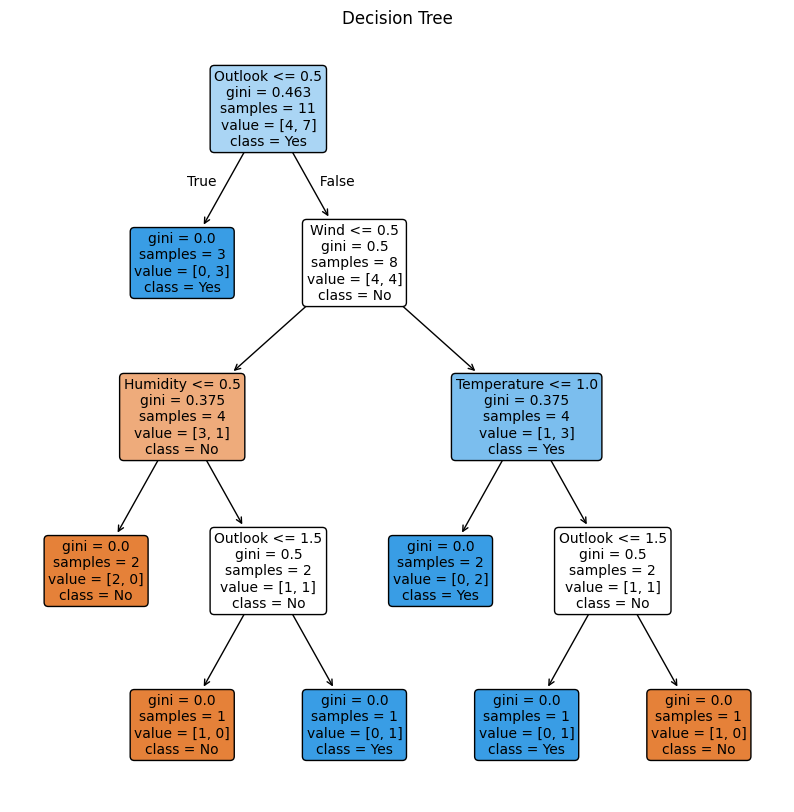

In [ ]:
from sklearn import tree

plt.figure(figsize=(10, 10))
tree.plot_tree(CLF, filled=True, feature_names=x.columns, class_names=play_encoder.categories_[0], rounded=True, fontsize=10) # type: ignore
plt.title("Decision Tree")
plt.show()

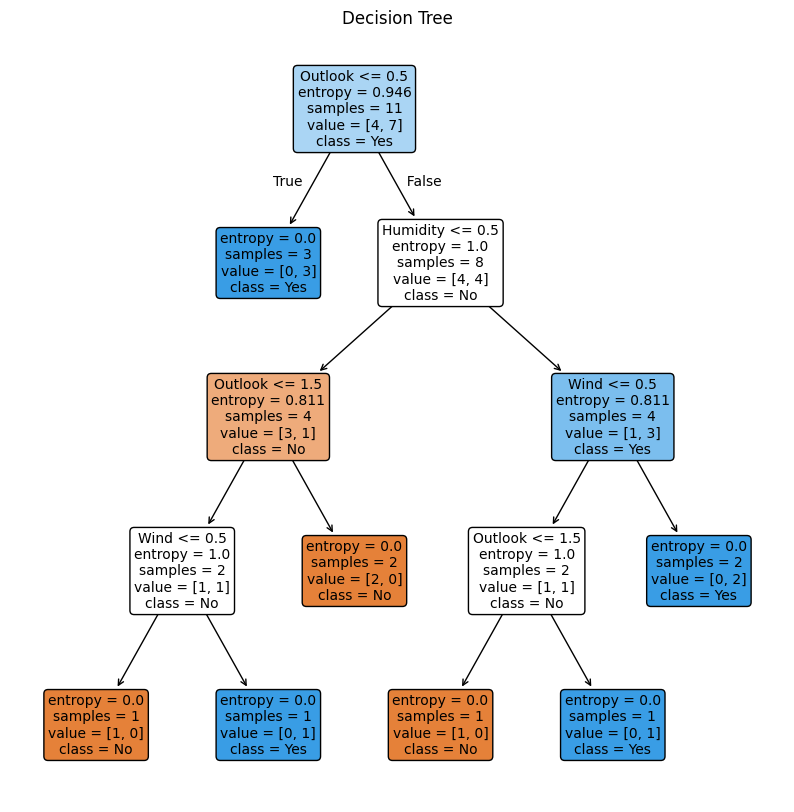

In [ ]:
from sklearn import tree

plt.figure(figsize=(10, 10))
tree.plot_tree(CLF_2, filled=True, feature_names=x.columns, class_names=play_encoder.categories_[0], rounded=True, fontsize=10) # type: ignore
plt.title("Decision Tree")
plt.show()